<a href="https://colab.research.google.com/github/OrestisGeo/streamify-ts-anomaly-detection/blob/main/notebooks/project2_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Contents:
1. Setup
2. Load TSB-UAD data
3. Generate Normality datasets
4. Offline baselines
5. SAND baseline
6. Streaming Variant 1
7. Streaming Variant 2
8. Evaluation
9. Results tables
10. Plots for poster

# 1. Setup

In [28]:
# Clone or update the public GitHub repository.
# No GitHub token is needed because the repository is public.

from pathlib import Path

username = "OrestisGeo"
repo = "streamify-ts-anomaly-detection"

repo_dir = Path(repo)

if not repo_dir.exists():
    !git clone https://github.com/{username}/{repo}.git
else:
    print(f"Repository already exists: {repo}")
    %cd {repo}
    !git pull --rebase origin main
    %cd ..

%cd {repo}

Cloning into 'streamify-ts-anomaly-detection'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 175 (delta 71), reused 113 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 4.34 MiB | 29.65 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/streamify-ts-anomaly-detection/streamify-ts-anomaly-detection/streamify-ts-anomaly-detection


In [29]:
%pip install -r requirements.txt

In [30]:
import sys
sys.path.append("/content/streamify-ts-anomaly-detection")

In [31]:
# Run the function that created the directories
from src.paths import (
    create_project_dirs,
    GENERATED_DATA_DIR,
    TABLES_DIR,
    OFFLINE_BASELINE_RESULTS_PATH,
    SAND_STREAMING_RESULTS_PATH,
    VARIANT1_BATCH_RESULTS_PATH,
    VARIANT2_ROLLING_RESULTS_PATH,
    ALL_RESULTS_PATH,
)

create_project_dirs()

In [32]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

RAW_DATA_DIR = Path("data/raw")

In [33]:

# Execution flags
# Keep these False during normal notebook use.
# Set a flag to True only when you want to recompute the corresponding results.

# Dataset access
# If False, the notebook expects the raw TSB-UAD dataset to already exist under data/raw/.
# If True, the notebook mounts Google Drive and links data/raw/ to GOOGLE_DRIVE_DATASET_DIR.
USE_GOOGLE_DRIVE_DATA = False

# Change this only if you want to use a TSB-UAD dataset stored in your own Google Drive.
GOOGLE_DRIVE_DATASET_DIR = "your_google_drive_folder_containing_TSB-UAD_dataset"

# Expensive computations
RUN_BUILD_INVENTORY = False
RUN_GENERATE_NORMALITIES = False
RUN_OFFLINE_BASELINES = False
RUN_SAND_BASELINE = False
RUN_VARIANT1_BATCH = False
RUN_VARIANT2_ROLLING = False
RUN_VARIANT2_FINETUNE_AE = False
RUN_VARIANT2_SELECTIVE_FINETUNE_AE = False

In [34]:
from src.dataset_inventory import (
    build_inventory,
    summarize_domains,
    filter_candidate_series,
)

#2. Load TSB-UAD data

In [35]:
# Optional Google Drive mount.
# This is only needed if USE_GOOGLE_DRIVE_DATA=True.
# If the dataset is already available under data/raw/, this cell skips Drive mounting.

if USE_GOOGLE_DRIVE_DATA:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Skipping Google Drive mount. Using local/repository data/raw/ instead.")

Skipping Google Drive mount. Using local/repository data/raw/ instead.


In [36]:

# Configure raw dataset location.
#
# Option 1 (default): USE_GOOGLE_DRIVE_DATA=False
#   The notebook expects the unzipped TSB-UAD dataset under data/raw/.
#
# Option 2: USE_GOOGLE_DRIVE_DATA=True
#   The notebook links data/raw/ to GOOGLE_DRIVE_DATASET_DIR in Google Drive.

from pathlib import Path
import os
import shutil

RAW_DATA_DIR = Path("data/raw")
drive_dataset_dir = Path(GOOGLE_DRIVE_DATASET_DIR)

if USE_GOOGLE_DRIVE_DATA:
    if not drive_dataset_dir.exists():
        raise FileNotFoundError(
            f"Google Drive dataset directory not found:\n{drive_dataset_dir}\n"
            "Update GOOGLE_DRIVE_DATASET_DIR in the flags cell."
        )

    Path("data").mkdir(parents=True, exist_ok=True)

    if RAW_DATA_DIR.exists() or RAW_DATA_DIR.is_symlink():
        if RAW_DATA_DIR.is_symlink() or RAW_DATA_DIR.is_file():
            RAW_DATA_DIR.unlink()
        else:
            shutil.rmtree(RAW_DATA_DIR)

    os.symlink(drive_dataset_dir, RAW_DATA_DIR)
    print("Linked data/raw/ to Google Drive dataset directory.")

else:
    if not RAW_DATA_DIR.exists():
        raise FileNotFoundError(
            "data/raw/ was not found.\n"
            "Place the unzipped TSB-UAD dataset under data/raw/ "
            "or set USE_GOOGLE_DRIVE_DATA=True and configure GOOGLE_DRIVE_DATASET_DIR."
        )

    print("Using existing data/raw/ directory.")

print("RAW_DATA_DIR:", RAW_DATA_DIR.resolve())
print("First items:")
for item in list(RAW_DATA_DIR.iterdir())[:10]:
    print(item)


Using existing data/raw/ directory.
RAW_DATA_DIR: /content/drive/MyDrive/Μεταπτυχιακό DWS/Datasets/TSB-UAD-Public/TSB-UAD-Public
First items:
data/raw/YAHOO
data/raw/Dodgers
data/raw/IOPS
data/raw/MGAB
data/raw/NAB
data/raw/NASA-MSL
data/raw/NASA-SMAP
data/raw/SensorScope
data/raw/KDD21
data/raw/ECG


In [37]:
from pathlib import Path
import os

print("cwd:", os.getcwd())
print("data exists:", Path("data").exists())
print("data/raw exists:", Path("data/raw").exists())

cwd: /content/streamify-ts-anomaly-detection/streamify-ts-anomaly-detection/streamify-ts-anomaly-detection
data exists: True
data/raw exists: True


In [38]:
from pathlib import Path

raw_dir = Path("data/raw")
print(list(raw_dir.iterdir())[:20])

[PosixPath('data/raw/YAHOO'), PosixPath('data/raw/Dodgers'), PosixPath('data/raw/IOPS'), PosixPath('data/raw/MGAB'), PosixPath('data/raw/NAB'), PosixPath('data/raw/NASA-MSL'), PosixPath('data/raw/NASA-SMAP'), PosixPath('data/raw/SensorScope'), PosixPath('data/raw/KDD21'), PosixPath('data/raw/ECG'), PosixPath('data/raw/GHL'), PosixPath('data/raw/Daphnet'), PosixPath('data/raw/MITDB'), PosixPath('data/raw/Genesis'), PosixPath('data/raw/Occupancy'), PosixPath('data/raw/OPPORTUNITY'), PosixPath('data/raw/SMD'), PosixPath('data/raw/SVDB'), PosixPath('data/raw/.DS_Store')]


In [39]:
kdd_dir = Path("data/raw/KDD21")
print(kdd_dir.exists())
if kdd_dir.exists():
    print(list(kdd_dir.iterdir())[:20])

True
[PosixPath('data/raw/KDD21/008_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature4_4000_5549_5597.out'), PosixPath('data/raw/KDD21/011_UCR_Anomaly_DISTORTEDECG1_10000_11800_12100.out'), PosixPath('data/raw/KDD21/010_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature6_4000_6006_6054.out'), PosixPath('data/raw/KDD21/005_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature1_4000_5391_5392.out'), PosixPath('data/raw/KDD21/001_UCR_Anomaly_DISTORTED1sddb40_35000_52000_52620.out'), PosixPath('data/raw/KDD21/004_UCR_Anomaly_DISTORTEDBIDMC1_2500_5400_5600.out'), PosixPath('data/raw/KDD21/012_UCR_Anomaly_DISTORTEDECG2_15000_16000_16100.out'), PosixPath('data/raw/KDD21/007_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature3_4000_6520_6544.out'), PosixPath('data/raw/KDD21/003_UCR_Anomaly_DISTORTED3sddb40_35000_46600_46900.out'), PosixPath('data/raw/KDD21/006_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature2_4000_5703_5727.out'), PosixPath('data/raw/KDD21/009_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature5_4000_4852_4900.out'), PosixPat

In [40]:
#label 1 is for anomaly points
import pandas as pd
path = RAW_DATA_DIR / "KDD21" / "004_UCR_Anomaly_DISTORTEDBIDMC1_2500_5400_5600.out"
df = pd.read_csv(path, header=None)
df.columns = ["value", "label"]

print(df.head())
print(df["label"].unique())

       value  label
0 -2785.9403    0.0
1 -3228.5676    0.0
2 -3528.9955    0.0
3 -4226.8308    0.0
4 -4508.2635    0.0
[0. 1.]


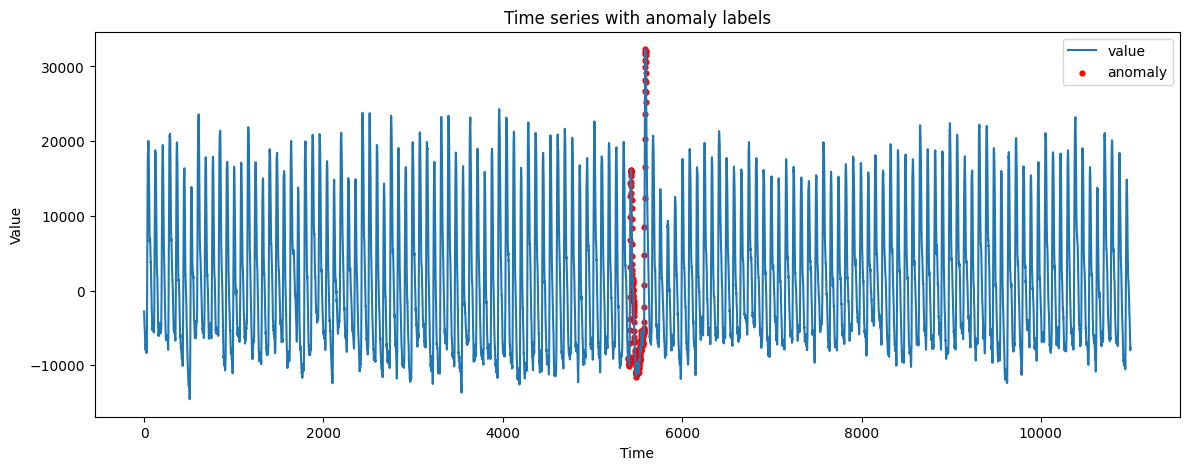

In [41]:
# Plot timeseries
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Enter the path of the timeseries you want to plot
path = Path("data/raw/KDD21/004_UCR_Anomaly_DISTORTEDBIDMC1_2500_5400_5600.out")
df = pd.read_csv(path, header=None, names=["value", "label"])

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["value"], label="value")
plt.scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="red",
    s=12,
    label="anomaly"
)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time series with anomaly labels")
plt.legend()
plt.show()

In [42]:
print(df["label"].value_counts())
print("Anomaly ratio:", df["label"].mean())

label
0.0    10800
1.0      200
Name: count, dtype: int64
Anomaly ratio: 0.01818181818181818


#3. Generate Normality datasets

In [43]:
# Choose time-series from different domains
# Check all files
from pathlib import Path

RAW_DATA_DIR = Path("data/raw")

out_files = list(RAW_DATA_DIR.rglob("*.out"))

print("Number of .out files found:", len(out_files))

for f in out_files[:10]:
    print(f)

Number of .out files found: 2062
data/raw/YAHOO/YahooA3Benchmark-TS19_data.out
data/raw/YAHOO/YahooA3Benchmark-TS100_data.out
data/raw/YAHOO/YahooA3Benchmark-TS14_data.out
data/raw/YAHOO/YahooA3Benchmark-TS29_data.out
data/raw/YAHOO/YahooA3Benchmark-TS33_data.out
data/raw/YAHOO/YahooA3Benchmark-TS20_data.out
data/raw/YAHOO/YahooA3Benchmark-TS26_data.out
data/raw/YAHOO/YahooA3Benchmark-TS24_data.out
data/raw/YAHOO/YahooA3Benchmark-TS11_data.out
data/raw/YAHOO/YahooA3Benchmark-TS28_data.out


In [44]:
example_file = out_files[0]

print("Example file:", example_file)

with open(example_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        print(f.readline())

Example file: data/raw/YAHOO/YahooA3Benchmark-TS19_data.out
43.2228342093602,0

451.91925680554,0

751.909561222081,0

927.93791140873,0

987.905534631611,0

839.402745645658,0

506.471468885842,0

155.113091712569,0

85.9373658100761,0

-156.322078704782,0



In [45]:
import pandas as pd

df = pd.read_csv(example_file)

print(df.shape)
df.head()

(1679, 2)


,43.2228342093602,0
0,451.919257,0
1,751.909561,0
2,927.937911,0
3,987.905535,0
4,839.402746,0


In [46]:
def read_out_file(path):
    """
    Reads a TSB-UAD .out file.

    Expected output:
    - first column: time-series value
    - second column: anomaly label
    """

    # First try normal CSV reading
    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, sep=None, engine="python", header=None)

    # If there is no proper header, assign names
    if df.shape[1] >= 2:
        # Keep only first two columns
        df = df.iloc[:, :2].copy()

        # If columns are not already value/label, rename them
        df.columns = ["value", "label"]
    else:
        raise ValueError(f"Could not read file correctly: {path}")

    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)

    return df

In [47]:
df = read_out_file(example_file)

print(df.shape)
df.head()

(1679, 2)


,value,label
0,451.919257,0
1,751.909561,0
2,927.937911,0
3,987.905535,0
4,839.402746,0


In [48]:
df["label"].value_counts()

,count
label,
0,1669
1,10


In [49]:
# Create or load the inventory with all the timeseries in the dataset
TABLES_DIR = Path("results/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

inventory_path = TABLES_DIR / "dataset_inventory.csv"

if RUN_BUILD_INVENTORY or not inventory_path.exists():
    print("Building inventory from raw files...")

    inventory = build_inventory(RAW_DATA_DIR)
    inventory.to_csv(inventory_path, index=False)

    print("Inventory created and saved to:", inventory_path)

else:
    print("Loading existing inventory from CSV...")

    inventory = pd.read_csv(inventory_path)

print("Inventory rows:", len(inventory))
inventory.head()

Loading existing inventory from CSV...
Inventory rows: 2062


,path,relative_path,domain,file_name,length,anomaly_count,anomaly_ratio,missing_values,value_mean,value_std
0,data/raw/YAHOO/YahooA3Benchmark-TS19_data.out,YAHOO/YahooA3Benchmark-TS19_data.out,YAHOO,YahooA3Benchmark-TS19_data.out,1679,10,0.005956,0,-840.066864,772.003291
1,data/raw/YAHOO/YahooA3Benchmark-TS100_data.out,YAHOO/YahooA3Benchmark-TS100_data.out,YAHOO,YahooA3Benchmark-TS100_data.out,1679,10,0.005956,0,0.040840,123.214107
2,data/raw/YAHOO/YahooA3Benchmark-TS14_data.out,YAHOO/YahooA3Benchmark-TS14_data.out,YAHOO,YahooA3Benchmark-TS14_data.out,1679,15,0.008934,0,-2522.871458,1464.382099
3,data/raw/YAHOO/YahooA3Benchmark-TS29_data.out,YAHOO/YahooA3Benchmark-TS29_data.out,YAHOO,YahooA3Benchmark-TS29_data.out,1679,4,0.002382,0,1683.166167,1026.430686
4,data/raw/YAHOO/YahooA3Benchmark-TS33_data.out,YAHOO/YahooA3Benchmark-TS33_data.out,YAHOO,YahooA3Benchmark-TS33_data.out,1679,8,0.004765,0,-6.928864,933.451987


In [50]:
# Load the already-created dataset inventory from CSV,
# summarizes the available time-series domains, applies the final stricter
# filtering criteria to select suitable candidate time series, and saves the
# resulting summary/candidate tables for later use.
#
# It does NOT rebuild the inventory from the raw .out files. Therefore, it is
# safe to run with "Run all" and avoids the expensive scan of the full dataset.

from pathlib import Path
import pandas as pd

from src.dataset_inventory import (
    summarize_domains,
    filter_candidate_series,
)

TABLES_DIR = Path("results/tables")
inventory_path = TABLES_DIR / "dataset_inventory.csv"

inventory = pd.read_csv(inventory_path)

print("Inventory rows:", len(inventory))

domain_summary = summarize_domains(inventory)

# Final stricter candidate filtering
candidates = filter_candidate_series(
    inventory,
    min_length=5000,
    max_length=50000,
    min_anomaly_ratio=0.002,
    max_anomaly_ratio=0.05,
)

print("Candidate time series after stricter filtering:", len(candidates))

domain_summary.to_csv(TABLES_DIR / "domain_summary.csv")
candidates.to_csv(TABLES_DIR / "dataset_candidates.csv", index=False)

candidate_domain_summary = (
    candidates
    .groupby("domain")
    .agg(
        n_candidates=("file_name", "count"),
        median_length=("length", "median"),
        min_length=("length", "min"),
        max_length=("length", "max"),
        median_anomaly_ratio=("anomaly_ratio", "median"),
    )
    .sort_values("n_candidates", ascending=False)
)

candidate_domain_summary.to_csv(TABLES_DIR / "candidate_domain_summary.csv")

display(domain_summary)
display(candidate_domain_summary)
display(candidates.head(30))

Inventory rows: 2062
Candidate time series after stricter filtering: 537


,n_series,median_length,min_length,max_length,median_anomaly_ratio
domain,,,,,
OPPORTUNITY,465,30526.0,22229,51115,0.038892
YAHOO,367,1679.0,740,1679,0.005360
SMD,281,23702.0,23686,28742,0.022876
KDD21,250,30065.0,6683,899999,0.003333
GHL,126,200000.0,200000,200000,0.000720
SVDB,115,230399.0,230399,230399,0.069970
NASA-SMAP,108,3666.0,311,8639,0.002031
NAB,58,4030.0,1125,22693,0.099580
IOPS,58,120465.5,7577,149160,0.013093


,n_candidates,median_length,min_length,max_length,median_anomaly_ratio
domain,,,,,
SMD,231,23702.0,23686,28742,0.015120
KDD21,120,11999.0,6683,39999,0.005866
OPPORTUNITY,120,30526.0,22229,42796,0.038892
NASA-SMAP,27,8204.0,7243,8639,0.011767
Daphnet,19,9599.0,9599,25599,0.027920
IOPS,12,8783.0,7577,11137,0.013695
Genesis,6,16219.0,16219,16219,0.003083
NASA-MSL,2,6099.0,6099,6099,0.025578


,path,relative_path,domain,file_name,length,anomaly_count,anomaly_ratio,missing_values,value_mean,value_std
1134,data/raw/Daphnet/S09R01E4.test.csv@2.out,Daphnet/S09R01E4.test.csv@2.out,Daphnet,S09R01E4.test.csv@2.out,9599,268,0.027920,0,1031.015939,235.550422
1135,data/raw/Daphnet/S03R03E4.test.csv@6.out,Daphnet/S03R03E4.test.csv@6.out,Daphnet,S03R03E4.test.csv@6.out,9599,268,0.027920,0,322.391603,300.656323
1137,data/raw/Daphnet/S09R01E4.test.csv@6.out,Daphnet/S09R01E4.test.csv@6.out,Daphnet,S09R01E4.test.csv@6.out,9599,268,0.027920,0,322.391603,300.656323
1142,data/raw/Daphnet/S09R01E4.test.csv@1.out,Daphnet/S09R01E4.test.csv@1.out,Daphnet,S09R01E4.test.csv@1.out,9599,268,0.027920,0,207.863111,356.203093
1144,data/raw/Daphnet/S03R03E4.test.csv@1.out,Daphnet/S03R03E4.test.csv@1.out,Daphnet,S03R03E4.test.csv@1.out,9599,268,0.027920,0,207.863111,356.203093
1145,data/raw/Daphnet/S09R01E4.test.csv@4.out,Daphnet/S09R01E4.test.csv@4.out,Daphnet,S09R01E4.test.csv@4.out,9599,268,0.027920,0,-368.989895,329.421888
1146,data/raw/Daphnet/S03R03E4.test.csv@2.out,Daphnet/S03R03E4.test.csv@2.out,Daphnet,S03R03E4.test.csv@2.out,9599,268,0.027920,0,1031.015939,235.550422
1147,data/raw/Daphnet/S03R03E4.test.csv@4.out,Daphnet/S03R03E4.test.csv@4.out,Daphnet,S03R03E4.test.csv@4.out,9599,268,0.027920,0,-368.989895,329.421888
1151,data/raw/Daphnet/S09R01E4.test.csv@3.out,Daphnet/S09R01E4.test.csv@3.out,Daphnet,S09R01E4.test.csv@3.out,9599,268,0.027920,0,137.701636,233.848897
1152,data/raw/Daphnet/S03R03E4.test.csv@3.out,Daphnet/S03R03E4.test.csv@3.out,Daphnet,S03R03E4.test.csv@3.out,9599,268,0.027920,0,137.701636,233.848897


In [51]:
# Pick 3 random time series from different domains
RANDOM_SEED = 80
N_SELECTED_SERIES = 3

# Shuffle candidates
shuffled_candidates = candidates.sample(
    frac=1,
    random_state=RANDOM_SEED
).copy()

# Keep one random time series per domain
selected_series = (
    shuffled_candidates
    .groupby("domain")
    .head(1)
    .sample(
        n=N_SELECTED_SERIES,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

selected_series["order"] = range(1, len(selected_series) + 1)

selected_series[
    [
        "order",
        "domain",
        "file_name",
        "length",
        "anomaly_count",
        "anomaly_ratio",
        "relative_path",
    ]
]

,order,domain,file_name,length,anomaly_count,anomaly_ratio,relative_path
0,1,SMD,machine-2-5.test.csv@9.out,23688,980,0.041371,SMD/machine-2-5.test.csv@9.out
1,2,OPPORTUNITY,S1-ADL3.test.csv@122.out,33272,1294,0.038892,OPPORTUNITY/S1-ADL3.test.csv@122.out
2,3,Daphnet,S09R01E0.test.csv@8.out,9599,323,0.033649,Daphnet/S09R01E0.test.csv@8.out


In [52]:
selected_series.to_csv(TABLES_DIR / "selected_series.csv", index=False)

print("Saved selected series to:", TABLES_DIR / "selected_series.csv")

Saved selected series to: results/tables/selected_series.csv


Order: 1
Domain: SMD
File: machine-2-5.test.csv@9.out
Length: 23688
Anomalies: 980
Anomaly ratio: 0.0414


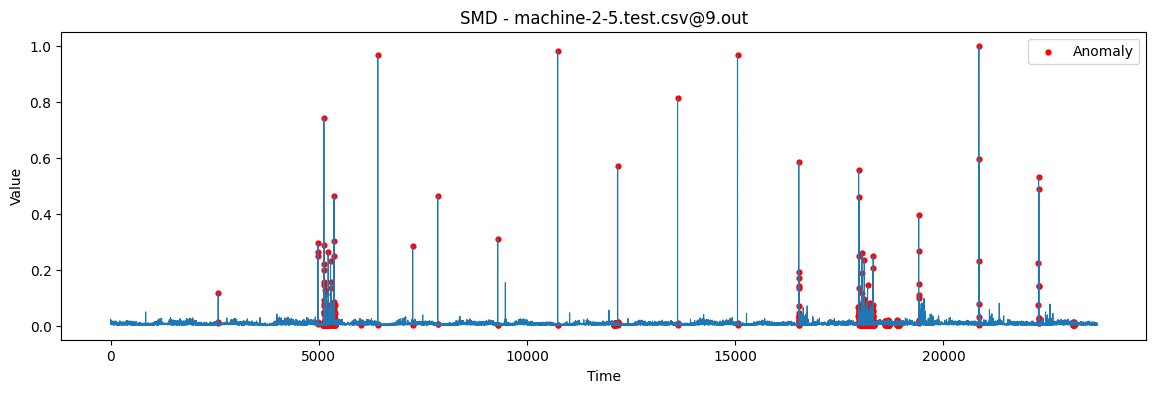

Order: 2
Domain: OPPORTUNITY
File: S1-ADL3.test.csv@122.out
Length: 33272
Anomalies: 1294
Anomaly ratio: 0.0389


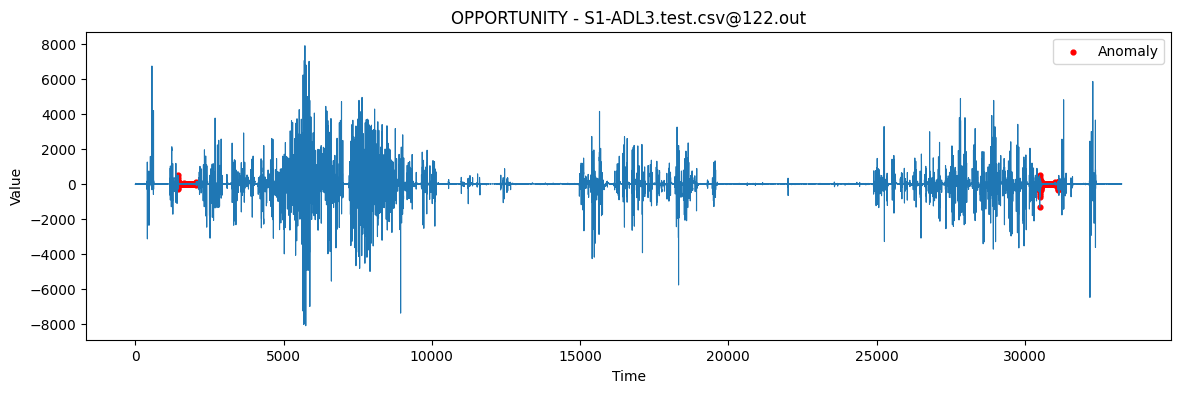

Order: 3
Domain: Daphnet
File: S09R01E0.test.csv@8.out
Length: 9599
Anomalies: 323
Anomaly ratio: 0.0336


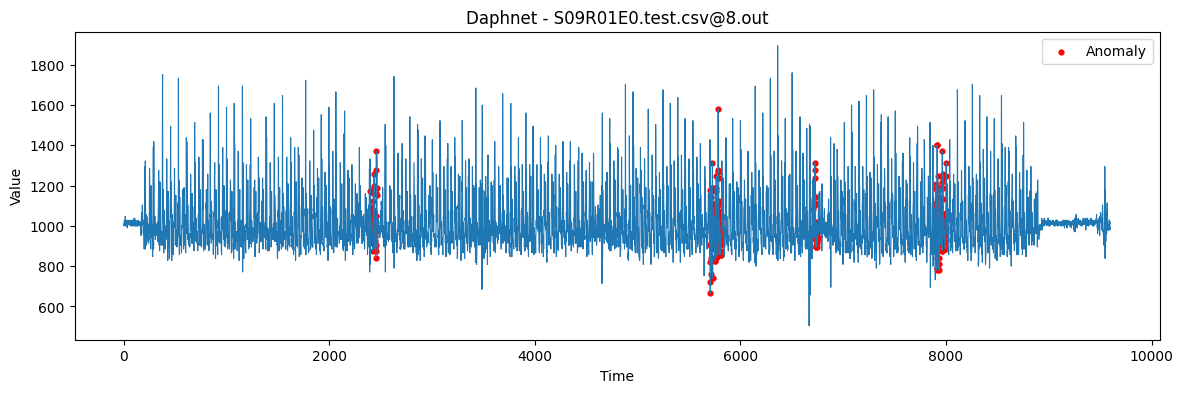

In [53]:
from pathlib import Path
import matplotlib.pyplot as plt

from src.data_loading import read_out_file

RAW_DATA_DIR = Path("data/raw")

for _, row in selected_series.iterrows():
    path = RAW_DATA_DIR / row["relative_path"]
    df = read_out_file(path)

    print("=" * 80)
    print("Order:", row["order"])
    print("Domain:", row["domain"])
    print("File:", row["file_name"])
    print("Length:", len(df))
    print("Anomalies:", int((df["label"] == 1).sum()))
    print("Anomaly ratio:", round((df["label"] == 1).mean(), 4))

    plt.figure(figsize=(14, 4))
    plt.plot(df["value"].values, linewidth=0.8)

    anomaly_idx = df.index[df["label"] == 1]
    plt.scatter(
    anomaly_idx,
    df.loc[anomaly_idx, "value"],
    s=12,
    color="red",
    label="Anomaly"
    )

    plt.title(f'{row["domain"]} - {row["file_name"]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

In [54]:
# Step 3: Generate Normality datasets
# This cell either loads the existing generated datasets summary
# or recomputes Normality 1/2/3 if RUN_GENERATE_NORMALITIES=True
# or if the generated summary file is missing.
#
# Normality 1 = first selected time series
# Normality 2 = first + second selected time series
# Normality 3 = first + second + third selected time series

from pathlib import Path
import pandas as pd

from src.dataset_generation import create_normality_datasets

RAW_DATA_DIR = Path("data/raw")
TABLES_DIR = Path("results/tables")
GENERATED_DATA_DIR = Path("data/generated")

selected_series_path = TABLES_DIR / "selected_series.csv"
generated_summary_path = GENERATED_DATA_DIR / "generated_datasets_summary.csv"

selected_series = pd.read_csv(selected_series_path)

display(selected_series[
    [
        "order",
        "domain",
        "file_name",
        "length",
        "anomaly_count",
        "anomaly_ratio",
        "relative_path",
    ]
])

if RUN_GENERATE_NORMALITIES or not generated_summary_path.exists():
    print("Generating Normality datasets...")

    generated_summary = create_normality_datasets(
        selected_series=selected_series,
        raw_data_dir=RAW_DATA_DIR,
        generated_data_dir=GENERATED_DATA_DIR,
        normalize=True,
    )

    print("Generated datasets saved under:", GENERATED_DATA_DIR)

else:
    print("Loading existing generated datasets summary...")

    generated_summary = pd.read_csv(generated_summary_path)

display(generated_summary)

,order,domain,file_name,length,anomaly_count,anomaly_ratio,relative_path
0,1,SMD,machine-2-5.test.csv@9.out,23688,980,0.041371,SMD/machine-2-5.test.csv@9.out
1,2,OPPORTUNITY,S1-ADL3.test.csv@122.out,33272,1294,0.038892,OPPORTUNITY/S1-ADL3.test.csv@122.out
2,3,Daphnet,S09R01E0.test.csv@8.out,9599,323,0.033649,Daphnet/S09R01E0.test.csv@8.out


Loading existing generated datasets summary...


,dataset_name,normality_level,n_segments,length,anomaly_count,anomaly_ratio,domains,distribution_shifts,boundary_indices,normalized_per_segment
0,normality_1.csv,1,1,23688,980,0.041371,SMD,0,[],True
1,normality_2.csv,2,2,56960,2274,0.039923,SMD + OPPORTUNITY,1,[23688],True
2,normality_3.csv,3,3,66559,2597,0.039018,SMD + OPPORTUNITY + Daphnet,2,"[23688, 56960]",True


In [55]:
!ls -lh data/generated

total 9.9M
-rw-r--r-- 1 root root  396 Jun  8 19:08 generated_datasets_summary.csv
-rw-r--r-- 1 root root 1.6M Jun  8 19:08 normality_1.csv
-rw-r--r-- 1 root root 3.9M Jun  8 19:08 normality_2.csv
-rw-r--r-- 1 root root 4.5M Jun  8 19:08 normality_3.csv


#4. Offline baselines

In [56]:
# Step 4: Offline baselines
# This cell either loads the already-computed offline baseline results
# or recomputes them if RUN_OFFLINE_BASELINES=True or the results file is missing.

from pathlib import Path
import pandas as pd

from src.offline_methods import (
    run_isolation_forest_offline,
    run_autoencoder_offline,
)

from src.evaluation import evaluate_scores

GENERATED_DATA_DIR = Path("data/generated")
TABLES_DIR = Path("results/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

offline_results_path = TABLES_DIR / "offline_baseline_results.csv"

WINDOW_SIZE = 100

if RUN_OFFLINE_BASELINES or not offline_results_path.exists():
    print("Running offline baselines...")

    results = []

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        print("=" * 80)
        print("Dataset:", dataset_path.name)

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        # Isolation Forest
        print("Running Isolation Forest...")

        if_scores, if_runtime = run_isolation_forest_offline(
            values=values,
            window_size=WINDOW_SIZE,
            n_estimators=100,
            contamination="auto",
            random_state=42,
        )

        if_result = evaluate_scores(
            scores=if_scores,
            labels=labels,
            method_name="Isolation Forest",
            dataset_name=dataset_path.name,
            runtime_seconds=if_runtime,
            setting="offline",
        )

        results.append(if_result)

        # Dense Autoencoder
        print("Running Dense Autoencoder...")

        ae_scores, ae_runtime = run_autoencoder_offline(
            values=values,
            window_size=WINDOW_SIZE,
            epochs=10,
            batch_size=256,
            random_state=42,
        )

        ae_result = evaluate_scores(
            scores=ae_scores,
            labels=labels,
            method_name="Dense Autoencoder",
            dataset_name=dataset_path.name,
            runtime_seconds=ae_runtime,
            setting="offline",
        )

        results.append(ae_result)

    offline_results = pd.DataFrame(results)

    offline_results.to_csv(
        offline_results_path,
        index=False,
    )

    print("Offline baseline results saved to:", offline_results_path)

else:
    print("Loading existing offline baseline results...")

    offline_results = pd.read_csv(offline_results_path)

display(offline_results)

Loading existing offline baseline results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Isolation Forest,offline,0.839464,0.523865,0.602041,0.602041,0.602041,0.382613,23688,980,0.041371
1,normality_1.csv,Dense Autoencoder,offline,0.841049,0.208961,0.250000,0.250000,0.250000,5.010207,23688,980,0.041371
2,normality_2.csv,Isolation Forest,offline,0.452324,0.044328,0.020668,0.020668,0.020668,0.696823,56960,2274,0.039923
3,normality_2.csv,Dense Autoencoder,offline,0.472309,0.069557,0.160510,0.160510,0.160510,9.721084,56960,2274,0.039923
4,normality_3.csv,Isolation Forest,offline,0.478513,0.043189,0.027339,0.027339,0.027339,0.670019,66559,2597,0.039018
5,normality_3.csv,Dense Autoencoder,offline,0.501622,0.072259,0.152099,0.152099,0.152099,11.384497,66559,2597,0.039018


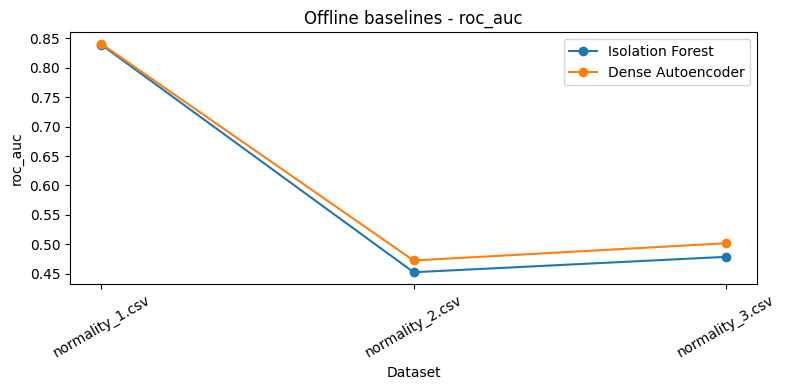

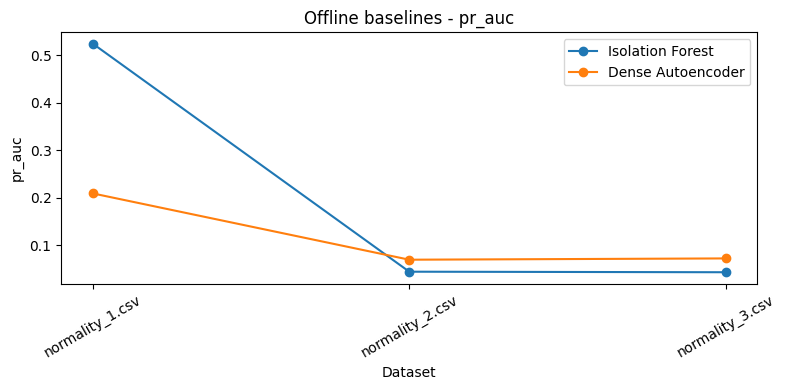

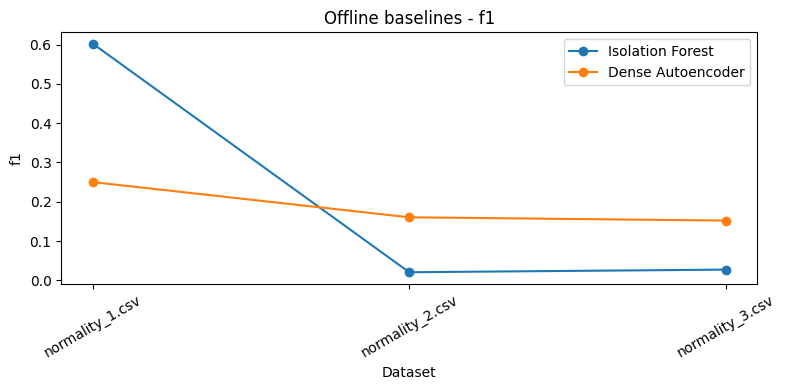

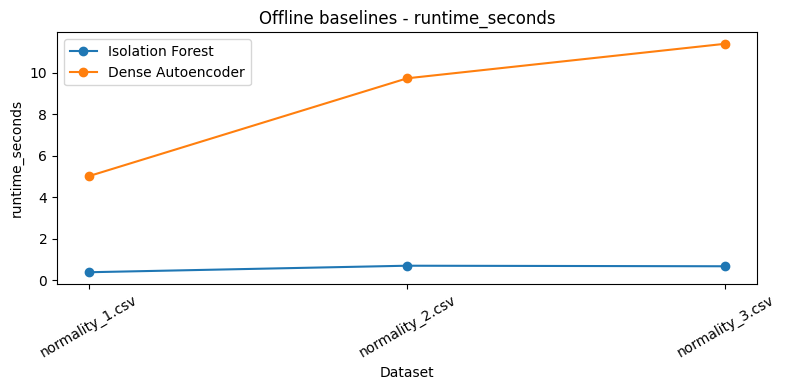

In [57]:
# Plot offline baseline results
import matplotlib.pyplot as plt

offline_results = pd.read_csv(TABLES_DIR / "offline_baseline_results.csv")

for metric in ["roc_auc", "pr_auc", "f1", "runtime_seconds"]:
    plt.figure(figsize=(8, 4))

    for method in offline_results["method"].unique():
        method_df = offline_results[offline_results["method"] == method]

        plt.plot(
            method_df["dataset"],
            method_df[metric],
            marker="o",
            label=method,
        )

    plt.title(f"Offline baselines - {metric}")
    plt.xlabel("Dataset")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

#5: SAND baseline

In [58]:
# Download the official TSB-UAD repository to use the SAND implementation.
# The repository is cloned under external/, which is ignored by Git.

from pathlib import Path

sand_repo_dir = Path("external/TSB-UAD")

if not sand_repo_dir.exists():
    print("Cloning official TSB-UAD repository...")

    !mkdir -p external
    !git clone https://github.com/TheDatumOrg/TSB-UAD.git external/TSB-UAD

else:
    print("Official TSB-UAD repository already exists:", sand_repo_dir)

Cloning official TSB-UAD repository...
Cloning into 'external/TSB-UAD'...
remote: Enumerating objects: 763, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 763 (delta 129), reused 91 (delta 91), pack-reused 588 (from 1)
Receiving objects: 100% (763/763), 76.98 MiB | 35.10 MiB/s, done.
Resolving deltas: 100% (389/389), done.


In [59]:
import importlib

import src.sand_baseline as sand_baseline
import src.evaluation as evaluation

sand_baseline = importlib.reload(sand_baseline)
evaluation = importlib.reload(evaluation)

run_sand_online = sand_baseline.run_sand_online
evaluate_scores = evaluation.evaluate_scores

In [60]:
# Load existing SAND streaming results if available.
# This avoids rerunning the expensive SAND baseline when starting a new session.

from pathlib import Path
import pandas as pd

TABLES_DIR = Path("results/tables")
sand_results_path = TABLES_DIR / "sand_streaming_results.csv"

if sand_results_path.exists():
    sand_results = pd.read_csv(sand_results_path)

    print("Loaded existing SAND results from:", sand_results_path)
    display(sand_results)

else:
    print("No SAND results file found yet.")
    print("Set RUN_SAND_BASELINE=True and run the next cell to compute SAND results.")

Loaded existing SAND results from: results/tables/sand_streaming_results.csv


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,SAND,streaming,0.606691,0.057398,0.041837,0.041837,0.041837,70.192729,23688,980,0.041371
1,normality_2.csv,SAND,streaming,0.558666,0.047245,0.061566,0.061566,0.061566,131.664044,56960,2274,0.039923
2,normality_3.csv,SAND,streaming,0.572924,0.045764,0.021563,0.021563,0.021563,178.528656,66559,2597,0.039018


In [61]:
# This cell runs SAND only if RUN_SAND_BASELINE=True or if the SAND results file is missing.
# If results already exist, it simply loads them.

from pathlib import Path
import pandas as pd
import importlib

import src.sand_baseline as sand_baseline
import src.evaluation as evaluation

sand_baseline = importlib.reload(sand_baseline)
evaluation = importlib.reload(evaluation)

run_sand_online = sand_baseline.run_sand_online
evaluate_scores = evaluation.evaluate_scores

GENERATED_DATA_DIR = Path("data/generated")
TABLES_DIR = Path("results/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sand_results_path = TABLES_DIR / "sand_streaming_results.csv"

SAND_PARAMS = {
    "pattern_length": 100,
    "subsequence_length": 100,
    "k": 6,
    "alpha": 0.5,
    "init_length": 3000,
    "batch_size": 1000,
    "overlaping_rate": 10,
}

if RUN_SAND_BASELINE or not sand_results_path.exists():
    print("Running SAND streaming baseline...")

    # Load existing partial results if they exist.
    # This allows the cell to continue from where it stopped.
    if sand_results_path.exists():
        sand_results = pd.read_csv(sand_results_path)
        completed_datasets = set(sand_results["dataset"].tolist())
        sand_results = sand_results.to_dict("records")
    else:
        sand_results = []
        completed_datasets = set()

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        if dataset_path.name in completed_datasets:
            print(f"Skipping {dataset_path.name} because it already exists in results.")
            continue

        print("=" * 80)
        print("Running SAND online on:", dataset_path.name)

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        sand_scores, sand_runtime = run_sand_online(
            values=values,
            labels=labels,
            **SAND_PARAMS,
        )

        result = evaluate_scores(
            scores=sand_scores,
            labels=labels,
            method_name="SAND",
            dataset_name=dataset_path.name,
            runtime_seconds=sand_runtime,
            setting="streaming",
        )

        sand_results.append(result)

        # Save after every dataset so progress is not lost if Colab disconnects.
        pd.DataFrame(sand_results).to_csv(sand_results_path, index=False)

        print("Saved intermediate results to:", sand_results_path)

    sand_results = pd.DataFrame(sand_results)

else:
    print("Loading existing SAND streaming results...")

    sand_results = pd.read_csv(sand_results_path)

display(sand_results)

Loading existing SAND streaming results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,SAND,streaming,0.606691,0.057398,0.041837,0.041837,0.041837,70.192729,23688,980,0.041371
1,normality_2.csv,SAND,streaming,0.558666,0.047245,0.061566,0.061566,0.061566,131.664044,56960,2274,0.039923
2,normality_3.csv,SAND,streaming,0.572924,0.045764,0.021563,0.021563,0.021563,178.528656,66559,2597,0.039018


In [62]:
# Combine offline and SAND baseline results.

from pathlib import Path
import pandas as pd

TABLES_DIR = Path("results/tables")

offline_results_path = TABLES_DIR / "offline_baseline_results.csv"
sand_results_path = TABLES_DIR / "sand_streaming_results.csv"
all_results_path = TABLES_DIR / "all_baseline_results.csv"

offline_results = pd.read_csv(offline_results_path)
sand_results = pd.read_csv(sand_results_path)

all_baseline_results = pd.concat(
    [offline_results, sand_results],
    ignore_index=True,
)

all_baseline_results.to_csv(
    all_results_path,
    index=False,
)

display(all_baseline_results)

,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Isolation Forest,offline,0.839464,0.523865,0.602041,0.602041,0.602041,0.382613,23688,980,0.041371
1,normality_1.csv,Dense Autoencoder,offline,0.841049,0.208961,0.250000,0.250000,0.250000,5.010207,23688,980,0.041371
2,normality_2.csv,Isolation Forest,offline,0.452324,0.044328,0.020668,0.020668,0.020668,0.696823,56960,2274,0.039923
3,normality_2.csv,Dense Autoencoder,offline,0.472309,0.069557,0.160510,0.160510,0.160510,9.721084,56960,2274,0.039923
4,normality_3.csv,Isolation Forest,offline,0.478513,0.043189,0.027339,0.027339,0.027339,0.670019,66559,2597,0.039018
5,normality_3.csv,Dense Autoencoder,offline,0.501622,0.072259,0.152099,0.152099,0.152099,11.384497,66559,2597,0.039018
6,normality_1.csv,SAND,streaming,0.606691,0.057398,0.041837,0.041837,0.041837,70.192729,23688,980,0.041371
7,normality_2.csv,SAND,streaming,0.558666,0.047245,0.061566,0.061566,0.061566,131.664044,56960,2274,0.039923
8,normality_3.csv,SAND,streaming,0.572924,0.045764,0.021563,0.021563,0.021563,178.528656,66559,2597,0.039018


#6 Streaming Variant 1

In [63]:
# Step 6 - Variant 1: Naive batch streaming
# This cell runs the two selected offline methods in a naive streaming setting.
# Each incoming batch is processed independently, without memory from previous batches.

from pathlib import Path
import pandas as pd
import importlib

import src.streaming_variants as streaming_variants
import src.evaluation as evaluation
import src.paths as paths

streaming_variants = importlib.reload(streaming_variants)
evaluation = importlib.reload(evaluation)
paths = importlib.reload(paths)

from src.streaming_variants import (
    run_batch_isolation_forest_streaming,
    run_batch_autoencoder_streaming,
)

from src.evaluation import evaluate_scores

from src.paths import (
    GENERATED_DATA_DIR,
    TABLES_DIR,
    VARIANT1_BATCH_RESULTS_PATH,
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)

STREAM_BATCH_SIZE = 5000
WINDOW_SIZE = 100

if RUN_VARIANT1_BATCH or not VARIANT1_BATCH_RESULTS_PATH.exists():
    print("Running Variant 1: naive batch streaming...")

    variant1_results = []

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        print("=" * 80)
        print("Dataset:", dataset_path.name)

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        # Batch Isolation Forest
        print("Running Batch Isolation Forest...")

        if_scores, if_runtime = run_batch_isolation_forest_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            n_estimators=100,
            contamination="auto",
            random_state=42,
        )

        if_result = evaluate_scores(
            scores=if_scores,
            labels=labels,
            method_name="Batch Isolation Forest",
            dataset_name=dataset_path.name,
            runtime_seconds=if_runtime,
            setting="streaming_variant_1",
        )

        variant1_results.append(if_result)

        # Batch Dense Autoencoder
        print("Running Batch Dense Autoencoder...")

        ae_scores, ae_runtime = run_batch_autoencoder_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            epochs=5,
            batch_size_training=256,
            random_state=42,
        )

        ae_result = evaluate_scores(
            scores=ae_scores,
            labels=labels,
            method_name="Batch Dense Autoencoder",
            dataset_name=dataset_path.name,
            runtime_seconds=ae_runtime,
            setting="streaming_variant_1",
        )

        variant1_results.append(ae_result)

        # Save intermediate results after each dataset
        pd.DataFrame(variant1_results).to_csv(
            VARIANT1_BATCH_RESULTS_PATH,
            index=False,
        )

    variant1_results = pd.DataFrame(variant1_results)

    print("Variant 1 results saved to:", VARIANT1_BATCH_RESULTS_PATH)

else:
    print("Loading existing Variant 1 results...")

    variant1_results = pd.read_csv(VARIANT1_BATCH_RESULTS_PATH)

display(variant1_results)

Loading existing Variant 1 results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Batch Isolation Forest,streaming_variant_1,0.745912,0.425359,0.493878,0.493878,0.493878,1.409002,23688,980,0.041371
1,normality_1.csv,Batch Dense Autoencoder,streaming_variant_1,0.837349,0.214849,0.278571,0.278571,0.278571,15.104505,23688,980,0.041371
2,normality_2.csv,Batch Isolation Forest,streaming_variant_1,0.493973,0.096839,0.231750,0.231750,0.231750,4.534357,56960,2274,0.039923
3,normality_2.csv,Batch Dense Autoencoder,streaming_variant_1,0.525215,0.070965,0.163588,0.163588,0.163588,36.426547,56960,2274,0.039923
4,normality_3.csv,Batch Isolation Forest,streaming_variant_1,0.501709,0.093704,0.211013,0.211013,0.211013,3.899189,66559,2597,0.039018
5,normality_3.csv,Batch Dense Autoencoder,streaming_variant_1,0.537549,0.071082,0.146323,0.146323,0.146323,42.538921,66559,2597,0.039018


#7. Streaming Variant 2 : Rolling-window streaming adaptation



In [64]:
# Step 7 - Variant 2: Rolling-window streaming
# This cell runs the two selected offline methods in an adaptive streaming setting.
# Each batch is processed together with a short recent history of previous batches.
# Only the scores of the current batch are kept for evaluation.

import pandas as pd
import importlib

import src.streaming_variants as streaming_variants
import src.evaluation as evaluation
import src.paths as paths

streaming_variants = importlib.reload(streaming_variants)
evaluation = importlib.reload(evaluation)
paths = importlib.reload(paths)

from src.streaming_variants import (
    run_rolling_isolation_forest_streaming,
    run_rolling_autoencoder_streaming,
)

from src.evaluation import evaluate_scores

from src.paths import (
    GENERATED_DATA_DIR,
    TABLES_DIR,
    VARIANT2_ROLLING_RESULTS_PATH,
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)

STREAM_BATCH_SIZE = 5000
WINDOW_SIZE = 100
HISTORY_BATCHES = 2

if RUN_VARIANT2_ROLLING or not VARIANT2_ROLLING_RESULTS_PATH.exists():
    print("Running Variant 2: rolling-window streaming...")

    variant2_results = []

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        print("=" * 80)
        print("Dataset:", dataset_path.name)

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        # Rolling-window Isolation Forest
        print("Running Rolling-window Isolation Forest...")

        if_scores, if_runtime = run_rolling_isolation_forest_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            history_batches=HISTORY_BATCHES,
            n_estimators=100,
            contamination="auto",
            random_state=42,
        )

        if_result = evaluate_scores(
            scores=if_scores,
            labels=labels,
            method_name="Rolling Isolation Forest",
            dataset_name=dataset_path.name,
            runtime_seconds=if_runtime,
            setting="streaming_variant_2",
        )

        variant2_results.append(if_result)

        # Rolling-window Dense Autoencoder
        print("Running Rolling-window Dense Autoencoder...")

        ae_scores, ae_runtime = run_rolling_autoencoder_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            history_batches=HISTORY_BATCHES,
            epochs=5,
            batch_size_training=256,
            random_state=42,
        )

        ae_result = evaluate_scores(
            scores=ae_scores,
            labels=labels,
            method_name="Rolling Dense Autoencoder",
            dataset_name=dataset_path.name,
            runtime_seconds=ae_runtime,
            setting="streaming_variant_2",
        )

        variant2_results.append(ae_result)

        # Save intermediate results after each dataset
        pd.DataFrame(variant2_results).to_csv(
            VARIANT2_ROLLING_RESULTS_PATH,
            index=False,
        )

    variant2_results = pd.DataFrame(variant2_results)

    print("Variant 2 results saved to:", VARIANT2_ROLLING_RESULTS_PATH)

else:
    print("Loading existing Variant 2 results...")

    variant2_results = pd.read_csv(VARIANT2_ROLLING_RESULTS_PATH)

display(variant2_results)

Loading existing Variant 2 results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Rolling Isolation Forest,streaming_variant_2,0.778083,0.512879,0.596939,0.596939,0.596939,1.806662,23688,980,0.041371
1,normality_1.csv,Rolling Dense Autoencoder,streaming_variant_2,0.839891,0.206340,0.260204,0.260204,0.260204,19.007355,23688,980,0.041371
2,normality_2.csv,Rolling Isolation Forest,streaming_variant_2,0.463049,0.159039,0.262973,0.262973,0.262973,5.045608,56960,2274,0.039923
3,normality_2.csv,Rolling Dense Autoencoder,streaming_variant_2,0.484704,0.068656,0.168865,0.168865,0.168865,50.019039,56960,2274,0.039923
4,normality_3.csv,Rolling Isolation Forest,streaming_variant_2,0.473943,0.146047,0.231806,0.231806,0.231806,4.861815,66559,2597,0.039018
5,normality_3.csv,Rolling Dense Autoencoder,streaming_variant_2,0.512072,0.069817,0.154794,0.154794,0.154794,56.713949,66559,2597,0.039018


# Try Online fine-tuning Autoencoder

In [65]:
# Step 7 - Variant 2 alternative for Dense Autoencoder:
# Online fine-tuning Autoencoder.
#
# This does not replace the existing Rolling Autoencoder results.
# It creates a separate result file so that both approaches can be compared.

from pathlib import Path
import pandas as pd
import importlib

import src.streaming_variants as streaming_variants
import src.evaluation as evaluation
import src.paths as paths

streaming_variants = importlib.reload(streaming_variants)
evaluation = importlib.reload(evaluation)
paths = importlib.reload(paths)

from src.streaming_variants import run_online_finetune_autoencoder_streaming
from src.evaluation import evaluate_scores
from src.paths import GENERATED_DATA_DIR, TABLES_DIR

TABLES_DIR.mkdir(parents=True, exist_ok=True)

VARIANT2_FINETUNE_AE_RESULTS_PATH = (
    TABLES_DIR / "variant2_finetune_autoencoder_results.csv"
)

STREAM_BATCH_SIZE = 5000
WINDOW_SIZE = 100

if RUN_VARIANT2_FINETUNE_AE or not VARIANT2_FINETUNE_AE_RESULTS_PATH.exists():
    print("Running Variant 2 alternative: Online fine-tuning Autoencoder...")

    finetune_ae_results = []

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        print("=" * 80)
        print("Dataset:", dataset_path.name)
        print("Running Online Fine-tuning Dense Autoencoder...")

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        ae_scores, ae_runtime = run_online_finetune_autoencoder_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            init_batches=1,
            initial_epochs=10,
            finetune_epochs=1,
            batch_size_training=256,
            random_state=42,
        )

        ae_result = evaluate_scores(
            scores=ae_scores,
            labels=labels,
            method_name="Online Fine-tuning Dense Autoencoder",
            dataset_name=dataset_path.name,
            runtime_seconds=ae_runtime,
            setting="streaming_variant_2_finetune",
        )

        finetune_ae_results.append(ae_result)

        # Save intermediate results after each dataset
        pd.DataFrame(finetune_ae_results).to_csv(
            VARIANT2_FINETUNE_AE_RESULTS_PATH,
            index=False,
        )

    finetune_ae_results = pd.DataFrame(finetune_ae_results)

    print(
        "Online fine-tuning AE results saved to:",
        VARIANT2_FINETUNE_AE_RESULTS_PATH,
    )

else:
    print("Loading existing Online fine-tuning AE results...")

    finetune_ae_results = pd.read_csv(VARIANT2_FINETUNE_AE_RESULTS_PATH)

display(finetune_ae_results)

Loading existing Online fine-tuning AE results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Online Fine-tuning Dense Autoencoder,streaming_variant_2_finetune,0.836828,0.219808,0.278571,0.278571,0.278571,5.423148,23688,980,0.041371
1,normality_2.csv,Online Fine-tuning Dense Autoencoder,streaming_variant_2_finetune,0.473939,0.064976,0.133245,0.133245,0.133245,8.291776,56960,2274,0.039923
2,normality_3.csv,Online Fine-tuning Dense Autoencoder,streaming_variant_2_finetune,0.492773,0.065823,0.133616,0.133616,0.133616,9.799961,66559,2597,0.039018


# Try Selective online fine-tuning Autoencoder

In [66]:
# Step 7 - Variant 2 alternative for Dense Autoencoder:
# Selective online fine-tuning Autoencoder.
#
# This method updates the Autoencoder only with windows that have low
# reconstruction error and are therefore considered more likely to be normal.
# It does not overwrite the Rolling Autoencoder or simple Fine-tuning AE results.

import pandas as pd
import importlib

import src.streaming_variants as streaming_variants
import src.evaluation as evaluation
import src.paths as paths

streaming_variants = importlib.reload(streaming_variants)
evaluation = importlib.reload(evaluation)
paths = importlib.reload(paths)

from src.streaming_variants import run_selective_finetune_autoencoder_streaming
from src.evaluation import evaluate_scores

from src.paths import (
    GENERATED_DATA_DIR,
    TABLES_DIR,
    VARIANT2_SELECTIVE_FINETUNE_AE_RESULTS_PATH,
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)

STREAM_BATCH_SIZE = 5000
WINDOW_SIZE = 100

if (
    RUN_VARIANT2_SELECTIVE_FINETUNE_AE
    or not VARIANT2_SELECTIVE_FINETUNE_AE_RESULTS_PATH.exists()
):
    print("Running Variant 2 alternative: Selective fine-tuning Autoencoder...")

    selective_finetune_ae_results = []

    generated_files = sorted(GENERATED_DATA_DIR.glob("normality_*.csv"))

    for dataset_path in generated_files:
        print("=" * 80)
        print("Dataset:", dataset_path.name)
        print("Running Selective Fine-tuning Dense Autoencoder...")

        df = pd.read_csv(dataset_path)

        values = df["value"].to_numpy()
        labels = df["label"].to_numpy()

        ae_scores, ae_runtime = run_selective_finetune_autoencoder_streaming(
            values=values,
            batch_size=STREAM_BATCH_SIZE,
            window_size=WINDOW_SIZE,
            init_batches=1,
            initial_epochs=10,
            finetune_epochs=1,
            batch_size_training=256,
            normal_fraction=0.8,
            random_state=42,
        )

        ae_result = evaluate_scores(
            scores=ae_scores,
            labels=labels,
            method_name="Selective Fine-tuning Dense Autoencoder",
            dataset_name=dataset_path.name,
            runtime_seconds=ae_runtime,
            setting="streaming_variant_2_selective_finetune",
        )

        selective_finetune_ae_results.append(ae_result)

        # Save intermediate results after each dataset
        pd.DataFrame(selective_finetune_ae_results).to_csv(
            VARIANT2_SELECTIVE_FINETUNE_AE_RESULTS_PATH,
            index=False,
        )

    selective_finetune_ae_results = pd.DataFrame(selective_finetune_ae_results)

    print(
        "Selective fine-tuning AE results saved to:",
        VARIANT2_SELECTIVE_FINETUNE_AE_RESULTS_PATH,
    )

else:
    print("Loading existing Selective fine-tuning AE results...")

    selective_finetune_ae_results = pd.read_csv(
        VARIANT2_SELECTIVE_FINETUNE_AE_RESULTS_PATH
    )

display(selective_finetune_ae_results)

Loading existing Selective fine-tuning AE results...


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio
0,normality_1.csv,Selective Fine-tuning Dense Autoencoder,streaming_variant_2_selective_finetune,0.830972,0.219288,0.284694,0.284694,0.284694,6.314512,23688,980,0.041371
1,normality_2.csv,Selective Fine-tuning Dense Autoencoder,streaming_variant_2_selective_finetune,0.444552,0.063989,0.135884,0.135884,0.135884,12.161737,56960,2274,0.039923
2,normality_3.csv,Selective Fine-tuning Dense Autoencoder,streaming_variant_2_selective_finetune,0.476919,0.065352,0.134001,0.134001,0.134001,10.273057,66559,2597,0.039018


# 8. Evalutation

In [97]:
# Final evaluation table
# This cell loads all selected result files, combines them into one table,
# and computes accuracy using the same top-k thresholding assumption used for F1.
#
# The Selective Fine-tuning Autoencoder is intentionally excluded from the
# final poster tables/plots. We keep only the Online Fine-tuning Autoencoder
# as the additional AE adaptation.

from pathlib import Path
import pandas as pd
import numpy as np

TABLES_DIR = Path("results/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

result_files = [
    "offline_baseline_results.csv",
    "sand_streaming_results.csv",
    "variant1_batch_results.csv",
    "variant2_rolling_results.csv",
    "variant2_finetune_autoencoder_results.csv",
    # "variant2_selective_finetune_autoencoder_results.csv",  # excluded from poster
]

frames = []

for file_name in result_files:
    path = TABLES_DIR / file_name

    if path.exists():
        df = pd.read_csv(path)
        df["source_file"] = file_name
        frames.append(df)
        print("Loaded:", path)
    else:
        print("Missing:", path)

if len(frames) == 0:
    raise FileNotFoundError("No result files were found in results/tables/.")

all_results = pd.concat(frames, ignore_index=True)

# Clean possible method-name typos
all_results["method"] = all_results["method"].replace({
    "Batch Islation Forest": "Batch Isolation Forest",
    "Rolling Isolation Fotes": "Rolling Isolation Forest",
})

# Safety filter: exclude Selective Fine-tuning even if it appears somewhere
excluded_methods = [
    "Selective Fine-tuning Dense Autoencoder",
]

all_results = all_results[
    ~all_results["method"].isin(excluded_methods)
].copy()

# Pretty dataset labels
all_results["dataset_label"] = (
    all_results["dataset"]
    .str.replace("normality_", "Normality ", regex=False)
    .str.replace(".csv", "", regex=False)
)

# Accuracy under top-k thresholding:
# predicted anomalies = true anomalies = n_anomalies
all_results["accuracy"] = (
    1
    - (2 * all_results["n_anomalies"] * (1 - all_results["f1"]))
    / all_results["n_points"]
)

# Keep accuracy inside valid range, just in case of tiny numerical issues
all_results["accuracy"] = all_results["accuracy"].clip(0, 1)

# Round values for easier reading
for col in [
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "runtime_seconds",
    "anomaly_ratio",
]:
    if col in all_results.columns:
        all_results[col] = all_results[col].round(4)

all_results = all_results.sort_values(
    by=["dataset_label", "setting", "method"]
).reset_index(drop=True)

all_results.to_csv(
    TABLES_DIR / "all_results.csv",
    index=False,
)

print("Saved final results table to:", TABLES_DIR / "all_results.csv")
display(all_results)

Loaded: results/tables/offline_baseline_results.csv
Loaded: results/tables/sand_streaming_results.csv
Loaded: results/tables/variant1_batch_results.csv
Loaded: results/tables/variant2_rolling_results.csv
Loaded: results/tables/variant2_finetune_autoencoder_results.csv
Saved final results table to: results/tables/all_results.csv


,dataset,method,setting,roc_auc,pr_auc,precision,recall,f1,runtime_seconds,n_points,n_anomalies,anomaly_ratio,source_file,dataset_label,accuracy
0,normality_1.csv,Dense Autoencoder,offline,0.8410,0.2090,0.2500,0.2500,0.2500,5.0102,23688,980,0.0414,offline_baseline_results.csv,Normality 1,0.9379
1,normality_1.csv,Isolation Forest,offline,0.8395,0.5239,0.6020,0.6020,0.6020,0.3826,23688,980,0.0414,offline_baseline_results.csv,Normality 1,0.9671
2,normality_1.csv,SAND,streaming,0.6067,0.0574,0.0418,0.0418,0.0418,70.1927,23688,980,0.0414,sand_streaming_results.csv,Normality 1,0.9207
3,normality_1.csv,Batch Dense Autoencoder,streaming_variant_1,0.8373,0.2148,0.2786,0.2786,0.2786,15.1045,23688,980,0.0414,variant1_batch_results.csv,Normality 1,0.9403
4,normality_1.csv,Batch Isolation Forest,streaming_variant_1,0.7459,0.4254,0.4939,0.4939,0.4939,1.4090,23688,980,0.0414,variant1_batch_results.csv,Normality 1,0.9581
5,normality_1.csv,Rolling Dense Autoencoder,streaming_variant_2,0.8399,0.2063,0.2602,0.2602,0.2602,19.0074,23688,980,0.0414,variant2_rolling_results.csv,Normality 1,0.9388
6,normality_1.csv,Rolling Isolation Forest,streaming_variant_2,0.7781,0.5129,0.5969,0.5969,0.5969,1.8067,23688,980,0.0414,variant2_rolling_results.csv,Normality 1,0.9666
7,normality_1.csv,Online Fine-tuning Dense Autoencoder,streaming_variant_2_finetune,0.8368,0.2198,0.2786,0.2786,0.2786,5.4231,23688,980,0.0414,variant2_finetune_autoencoder_results.csv,Normality 1,0.9403
8,normality_2.csv,Dense Autoencoder,offline,0.4723,0.0696,0.1605,0.1605,0.1605,9.7211,56960,2274,0.0399,offline_baseline_results.csv,Normality 2,0.9330
9,normality_2.csv,Isolation Forest,offline,0.4523,0.0443,0.0207,0.0207,0.0207,0.6968,56960,2274,0.0399,offline_baseline_results.csv,Normality 2,0.9218


#9. Results Tables

In [98]:
# Poster Table 1: Dataset construction / Normality levels

from pathlib import Path
import pandas as pd

GENERATED_DATA_DIR = Path("data/generated")
TABLES_DIR = Path("results/tables")

generated_summary_path = GENERATED_DATA_DIR / "generated_datasets_summary.csv"

if not generated_summary_path.exists():
    raise FileNotFoundError(
        f"Missing generated dataset summary: {generated_summary_path}"
    )

generated_summary = pd.read_csv(generated_summary_path)

poster_dataset_table = generated_summary.copy()

# Create readable dataset name
if "normality_level" in poster_dataset_table.columns:
    poster_dataset_table["Dataset"] = (
        "Normality " + poster_dataset_table["normality_level"].astype(str)
    )
else:
    poster_dataset_table["Dataset"] = poster_dataset_table["dataset"]

# Convert anomaly ratio to percentage
poster_dataset_table["Anomaly Ratio (%)"] = (
    poster_dataset_table["anomaly_ratio"] * 100
).round(2)

# Keep only useful poster columns
possible_columns = {
    "domains": "Domains",
    "length": "Length",
    "anomaly_count": "Anomalies",
    "distribution_shifts": "Distribution Shifts",
}

columns_to_keep = ["Dataset"]

for old_col, new_col in possible_columns.items():
    if old_col in poster_dataset_table.columns:
        poster_dataset_table[new_col] = poster_dataset_table[old_col]
        columns_to_keep.append(new_col)

columns_to_keep.append("Anomaly Ratio (%)")

poster_dataset_table = poster_dataset_table[columns_to_keep]

poster_dataset_table.to_csv(
    TABLES_DIR / "poster_dataset_table.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_dataset_table.csv")
display(poster_dataset_table)

Saved: results/tables/poster_dataset_table.csv


,Dataset,Domains,Length,Anomalies,Distribution Shifts,Anomaly Ratio (%)
0,Normality 1,SMD,23688,980,0,4.14
1,Normality 2,SMD + OPPORTUNITY,56960,2274,1,3.99
2,Normality 3,SMD + OPPORTUNITY + Daphnet,66559,2597,2,3.90


In [99]:
# Poster Table 2: Methods overview

poster_methods_table = pd.DataFrame([
    {
        "Method": "Isolation Forest",
        "Type": "Classical ML",
        "Setting": "Offline",
        "Adaptation": "Full generated dataset is available"
    },
    {
        "Method": "Dense Autoencoder",
        "Type": "Neural reconstruction",
        "Setting": "Offline",
        "Adaptation": "Trained on all sliding windows"
    },
    {
        "Method": "SAND",
        "Type": "Streaming time-series method",
        "Setting": "Streaming baseline",
        "Adaptation": "Official online implementation"
    },
    {
        "Method": "Batch Isolation Forest",
        "Type": "Classical ML",
        "Setting": "Streaming Variant 1",
        "Adaptation": "Each batch is processed independently"
    },
    {
        "Method": "Batch Dense Autoencoder",
        "Type": "Neural reconstruction",
        "Setting": "Streaming Variant 1",
        "Adaptation": "Each batch is processed independently"
    },
    {
        "Method": "Rolling Isolation Forest",
        "Type": "Classical ML",
        "Setting": "Streaming Variant 2",
        "Adaptation": "Current batch + recent history"
    },
    {
        "Method": "Rolling Dense Autoencoder",
        "Type": "Neural reconstruction",
        "Setting": "Streaming Variant 2",
        "Adaptation": "Current batch + recent history"
    },
    {
        "Method": "Online Fine-tuning Dense Autoencoder",
        "Type": "Neural reconstruction",
        "Setting": "Additional AE variant",
        "Adaptation": "Initial training + incremental fine-tuning"
    },
])

poster_methods_table.to_csv(
    TABLES_DIR / "poster_methods_table.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_methods_table.csv")
display(poster_methods_table)

Saved: results/tables/poster_methods_table.csv


,Method,Type,Setting,Adaptation
0,Isolation Forest,Classical ML,Offline,Full generated dataset is available
1,Dense Autoencoder,Neural reconstruction,Offline,Trained on all sliding windows
2,SAND,Streaming time-series method,Streaming baseline,Official online implementation
3,Batch Isolation Forest,Classical ML,Streaming Variant 1,Each batch is processed independently
4,Batch Dense Autoencoder,Neural reconstruction,Streaming Variant 1,Each batch is processed independently
5,Rolling Isolation Forest,Classical ML,Streaming Variant 2,Current batch + recent history
6,Rolling Dense Autoencoder,Neural reconstruction,Streaming Variant 2,Current batch + recent history
7,Online Fine-tuning Dense Autoencoder,Neural reconstruction,Additional AE variant,Initial training + incremental fine-tuning


In [100]:
# Poster Table 3: Main results

all_results = pd.read_csv(TABLES_DIR / "all_results.csv")

main_methods = [
    "Isolation Forest",
    "Dense Autoencoder",
    "SAND",
    "Batch Isolation Forest",
    "Batch Dense Autoencoder",
    "Rolling Isolation Forest",
    "Rolling Dense Autoencoder",
]

poster_main_results = all_results[
    all_results["method"].isin(main_methods)
].copy()

poster_main_results = poster_main_results[
    [
        "dataset_label",
        "method",
        "roc_auc",
        "pr_auc",
        "f1",
        "accuracy",
        "runtime_seconds",
    ]
].rename(columns={
    "dataset_label": "Dataset",
    "method": "Method",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "runtime_seconds": "Runtime (s)",
})

poster_main_results.to_csv(
    TABLES_DIR / "poster_main_results.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_main_results.csv")
display(poster_main_results)

Saved: results/tables/poster_main_results.csv


,Dataset,Method,ROC-AUC,PR-AUC,F1,Accuracy,Runtime (s)
0,Normality 1,Dense Autoencoder,0.8410,0.2090,0.2500,0.9379,5.0102
1,Normality 1,Isolation Forest,0.8395,0.5239,0.6020,0.9671,0.3826
2,Normality 1,SAND,0.6067,0.0574,0.0418,0.9207,70.1927
3,Normality 1,Batch Dense Autoencoder,0.8373,0.2148,0.2786,0.9403,15.1045
4,Normality 1,Batch Isolation Forest,0.7459,0.4254,0.4939,0.9581,1.4090
5,Normality 1,Rolling Dense Autoencoder,0.8399,0.2063,0.2602,0.9388,19.0074
6,Normality 1,Rolling Isolation Forest,0.7781,0.5129,0.5969,0.9666,1.8067
8,Normality 2,Dense Autoencoder,0.4723,0.0696,0.1605,0.9330,9.7211
9,Normality 2,Isolation Forest,0.4523,0.0443,0.0207,0.9218,0.6968
10,Normality 2,SAND,0.5587,0.0472,0.0616,0.9251,131.6640


In [101]:
# Poster Table 4: Variant 1 vs Variant 2 comparison

all_results = pd.read_csv(TABLES_DIR / "all_results.csv")

variant_methods = all_results[
    all_results["method"].isin([
        "Batch Isolation Forest",
        "Rolling Isolation Forest",
        "Batch Dense Autoencoder",
        "Rolling Dense Autoencoder",
    ])
].copy()

variant_methods["Base Method"] = variant_methods["method"].replace({
    "Batch Isolation Forest": "Isolation Forest",
    "Rolling Isolation Forest": "Isolation Forest",
    "Batch Dense Autoencoder": "Dense Autoencoder",
    "Rolling Dense Autoencoder": "Dense Autoencoder",
})

variant_methods["Variant"] = variant_methods["method"].replace({
    "Batch Isolation Forest": "Variant 1 Batch",
    "Batch Dense Autoencoder": "Variant 1 Batch",
    "Rolling Isolation Forest": "Variant 2 Rolling",
    "Rolling Dense Autoencoder": "Variant 2 Rolling",
})

comparison = variant_methods.pivot_table(
    index=["dataset_label", "Base Method"],
    columns="Variant",
    values=["pr_auc", "f1", "accuracy", "runtime_seconds"],
    aggfunc="first",
)

comparison.columns = [
    "_".join(col).strip()
    for col in comparison.columns.to_flat_index()
]

comparison = comparison.reset_index()

comparison["ΔPR-AUC"] = (
    comparison["pr_auc_Variant 2 Rolling"]
    - comparison["pr_auc_Variant 1 Batch"]
).round(4)

comparison["ΔF1"] = (
    comparison["f1_Variant 2 Rolling"]
    - comparison["f1_Variant 1 Batch"]
).round(4)

comparison["ΔAccuracy"] = (
    comparison["accuracy_Variant 2 Rolling"]
    - comparison["accuracy_Variant 1 Batch"]
).round(4)

comparison["ΔRuntime (s)"] = (
    comparison["runtime_seconds_Variant 2 Rolling"]
    - comparison["runtime_seconds_Variant 1 Batch"]
).round(2)

poster_variant_comparison = comparison.rename(columns={
    "dataset_label": "Dataset",
    "pr_auc_Variant 1 Batch": "Variant 1 PR-AUC",
    "pr_auc_Variant 2 Rolling": "Variant 2 PR-AUC",
    "f1_Variant 1 Batch": "Variant 1 F1",
    "f1_Variant 2 Rolling": "Variant 2 F1",
    "accuracy_Variant 1 Batch": "Variant 1 Accuracy",
    "accuracy_Variant 2 Rolling": "Variant 2 Accuracy",
    "runtime_seconds_Variant 1 Batch": "Variant 1 Runtime (s)",
    "runtime_seconds_Variant 2 Rolling": "Variant 2 Runtime (s)",
})

poster_variant_comparison.to_csv(
    TABLES_DIR / "poster_variant_comparison.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_variant_comparison.csv")
display(poster_variant_comparison)

Saved: results/tables/poster_variant_comparison.csv


,Dataset,Base Method,Variant 1 Accuracy,Variant 2 Accuracy,Variant 1 F1,Variant 2 F1,Variant 1 PR-AUC,Variant 2 PR-AUC,Variant 1 Runtime (s),Variant 2 Runtime (s),ΔPR-AUC,ΔF1,ΔAccuracy,ΔRuntime (s)
0,Normality 1,Dense Autoencoder,0.9403,0.9388,0.2786,0.2602,0.2148,0.2063,15.1045,19.0074,-0.0085,-0.0184,-0.0015,3.90
1,Normality 1,Isolation Forest,0.9581,0.9666,0.4939,0.5969,0.4254,0.5129,1.4090,1.8067,0.0875,0.1030,0.0085,0.40
2,Normality 2,Dense Autoencoder,0.9332,0.9336,0.1636,0.1689,0.0710,0.0687,36.4265,50.0190,-0.0023,0.0053,0.0004,13.59
3,Normality 2,Isolation Forest,0.9387,0.9412,0.2318,0.2630,0.0968,0.1590,4.5344,5.0456,0.0622,0.0312,0.0025,0.51
4,Normality 3,Dense Autoencoder,0.9334,0.9340,0.1463,0.1548,0.0711,0.0698,42.5389,56.7139,-0.0013,0.0085,0.0006,14.18
5,Normality 3,Isolation Forest,0.9384,0.9401,0.2110,0.2318,0.0937,0.1460,3.8992,4.8618,0.0523,0.0208,0.0017,0.96


In [102]:
# Poster Table 5: Autoencoder variants
# Selective Fine-tuning is excluded from the final poster comparison.

all_results = pd.read_csv(TABLES_DIR / "all_results.csv")

ae_methods = [
    "Dense Autoencoder",
    "Batch Dense Autoencoder",
    "Rolling Dense Autoencoder",
    "Online Fine-tuning Dense Autoencoder",
]

poster_ae_variants = all_results[
    all_results["method"].isin(ae_methods)
].copy()

poster_ae_variants = poster_ae_variants[
    [
        "dataset_label",
        "method",
        "roc_auc",
        "pr_auc",
        "f1",
        "accuracy",
        "runtime_seconds",
    ]
].rename(columns={
    "dataset_label": "Dataset",
    "method": "AE Variant",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "runtime_seconds": "Runtime (s)",
})

poster_ae_variants.to_csv(
    TABLES_DIR / "poster_ae_variants.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_ae_variants.csv")
display(poster_ae_variants)

Saved: results/tables/poster_ae_variants.csv


,Dataset,AE Variant,ROC-AUC,PR-AUC,F1,Accuracy,Runtime (s)
0,Normality 1,Dense Autoencoder,0.8410,0.2090,0.2500,0.9379,5.0102
3,Normality 1,Batch Dense Autoencoder,0.8373,0.2148,0.2786,0.9403,15.1045
5,Normality 1,Rolling Dense Autoencoder,0.8399,0.2063,0.2602,0.9388,19.0074
7,Normality 1,Online Fine-tuning Dense Autoencoder,0.8368,0.2198,0.2786,0.9403,5.4231
8,Normality 2,Dense Autoencoder,0.4723,0.0696,0.1605,0.9330,9.7211
11,Normality 2,Batch Dense Autoencoder,0.5252,0.0710,0.1636,0.9332,36.4265
13,Normality 2,Rolling Dense Autoencoder,0.4847,0.0687,0.1689,0.9336,50.0190
15,Normality 2,Online Fine-tuning Dense Autoencoder,0.4739,0.0650,0.1332,0.9308,8.2918
16,Normality 3,Dense Autoencoder,0.5016,0.0723,0.1521,0.9338,11.3845
19,Normality 3,Batch Dense Autoencoder,0.5375,0.0711,0.1463,0.9334,42.5389


In [103]:
# Poster Table 6: Best method per dataset and metric

all_results = pd.read_csv(TABLES_DIR / "all_results.csv")

metrics = ["roc_auc", "pr_auc", "f1", "accuracy"]

best_rows = []

for dataset_label, group in all_results.groupby("dataset_label"):
    for metric in metrics:
        idx = group[metric].idxmax()

        best_rows.append({
            "Dataset": dataset_label,
            "Metric": metric.upper().replace("_", "-"),
            "Best Method": group.loc[idx, "method"],
            "Score": round(group.loc[idx, metric], 4),
        })

poster_best_methods = pd.DataFrame(best_rows)

poster_best_methods.to_csv(
    TABLES_DIR / "poster_best_methods.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_best_methods.csv")
display(poster_best_methods)

Saved: results/tables/poster_best_methods.csv


,Dataset,Metric,Best Method,Score
0,Normality 1,ROC-AUC,Dense Autoencoder,0.8410
1,Normality 1,PR-AUC,Isolation Forest,0.5239
2,Normality 1,F1,Isolation Forest,0.6020
3,Normality 1,ACCURACY,Isolation Forest,0.9671
4,Normality 2,ROC-AUC,SAND,0.5587
5,Normality 2,PR-AUC,Rolling Isolation Forest,0.1590
6,Normality 2,F1,Rolling Isolation Forest,0.2630
7,Normality 2,ACCURACY,Rolling Isolation Forest,0.9412
8,Normality 3,ROC-AUC,SAND,0.5729
9,Normality 3,PR-AUC,Rolling Isolation Forest,0.1460


# 10. Plots for poster

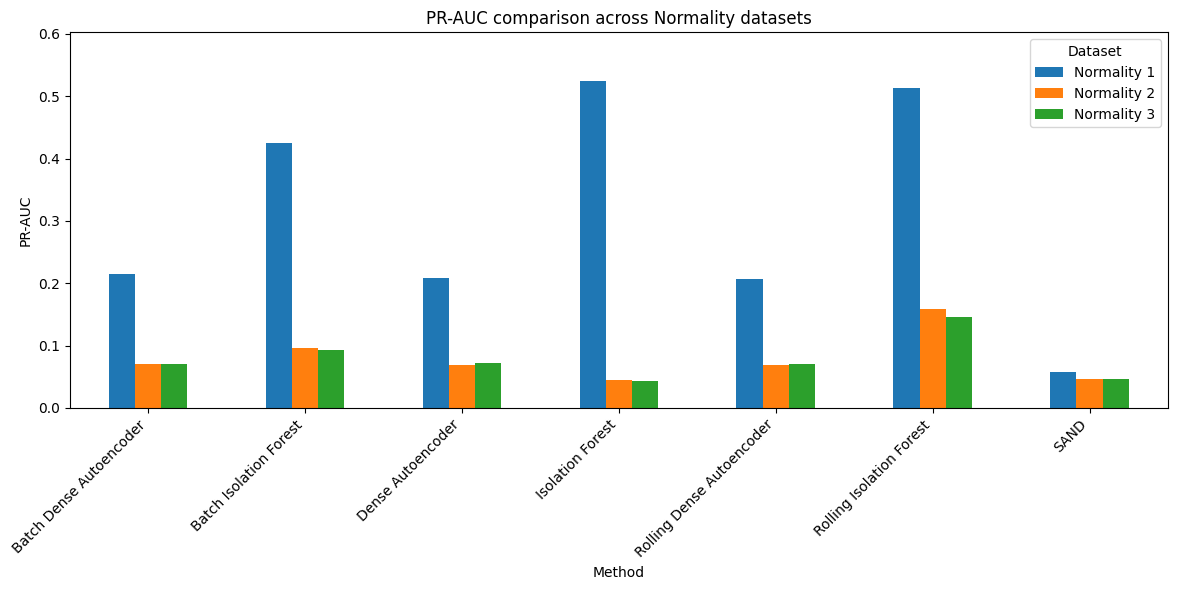

Saved: results/plots/poster_pr_auc_comparison.png


In [104]:
# Poster Plot 1: PR-AUC comparison

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("results/tables")
PLOTS_DIR = Path("results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

poster_main_results = pd.read_csv(TABLES_DIR / "poster_main_results.csv")

plot_df = poster_main_results.pivot(
    index="Method",
    columns="Dataset",
    values="PR-AUC"
)

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("PR-AUC comparison across Normality datasets")
ax.set_xlabel("Method")
ax.set_ylabel("PR-AUC")
ax.set_ylim(0, max(0.1, plot_df.max().max() * 1.15))
ax.legend(title="Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = PLOTS_DIR / "poster_pr_auc_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

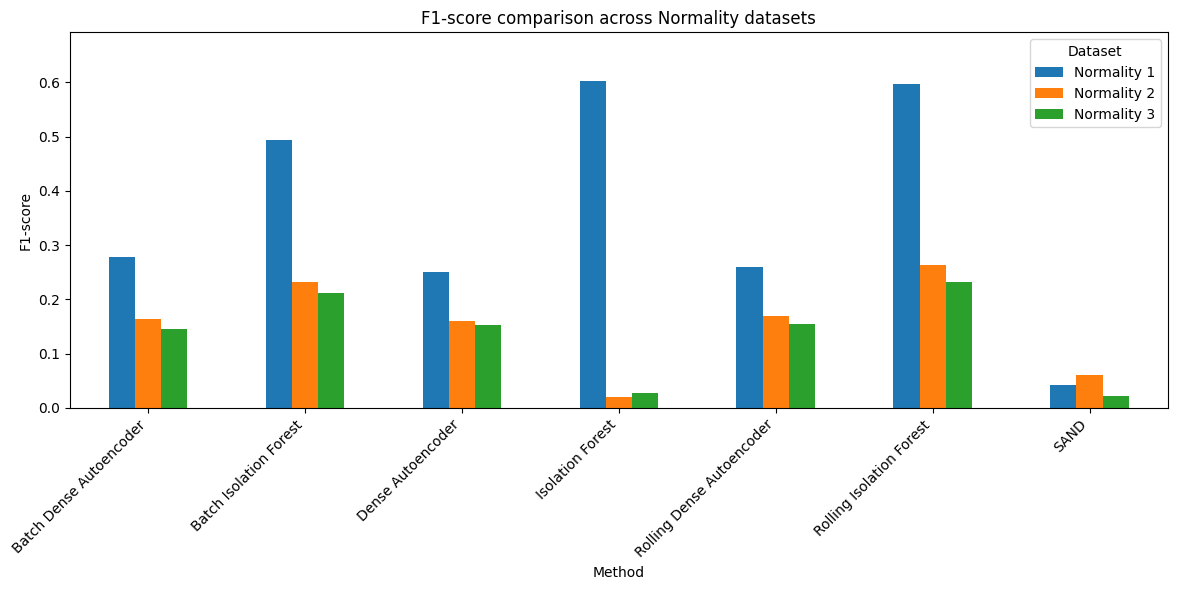

Saved: results/plots/poster_f1_comparison.png


In [105]:
# Poster Plot 2: F1 comparison

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("results/tables")
PLOTS_DIR = Path("results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

poster_main_results = pd.read_csv(TABLES_DIR / "poster_main_results.csv")

plot_df = poster_main_results.pivot(
    index="Method",
    columns="Dataset",
    values="F1"
)

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("F1-score comparison across Normality datasets")
ax.set_xlabel("Method")
ax.set_ylabel("F1-score")
ax.set_ylim(0, max(0.1, plot_df.max().max() * 1.15))
ax.legend(title="Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = PLOTS_DIR / "poster_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

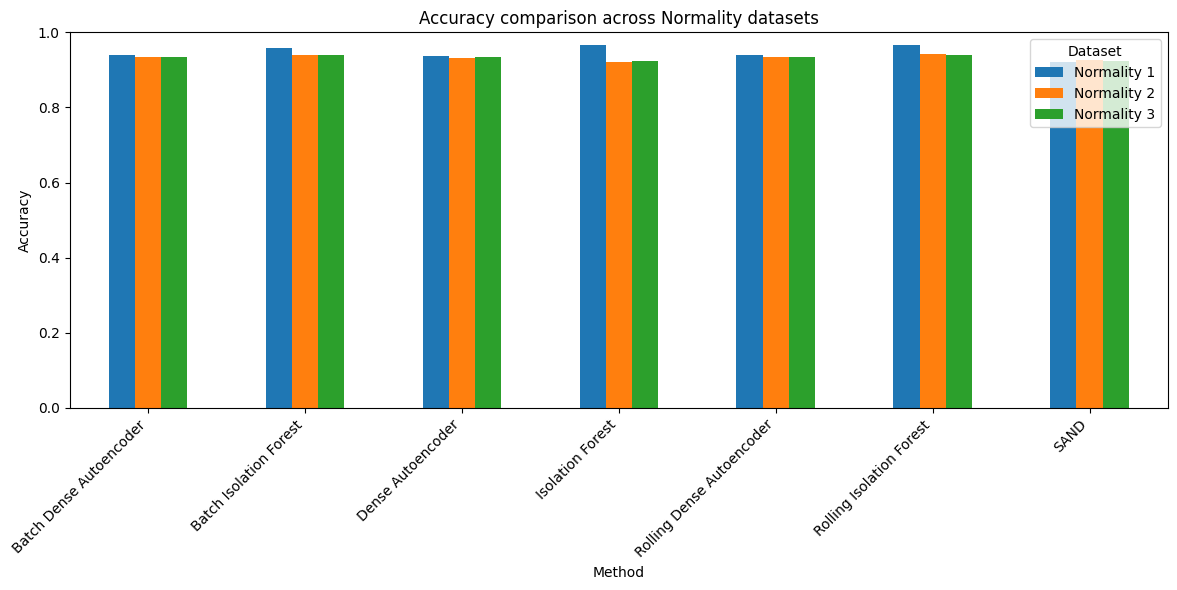

Saved: results/plots/poster_accuracy_comparison.png


In [106]:
# Poster Plot 3: Accuracy comparison

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("results/tables")
PLOTS_DIR = Path("results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

poster_main_results = pd.read_csv(TABLES_DIR / "poster_main_results.csv")

plot_df = poster_main_results.pivot(
    index="Method",
    columns="Dataset",
    values="Accuracy"
)

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("Accuracy comparison across Normality datasets")
ax.set_xlabel("Method")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.legend(title="Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = PLOTS_DIR / "poster_accuracy_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

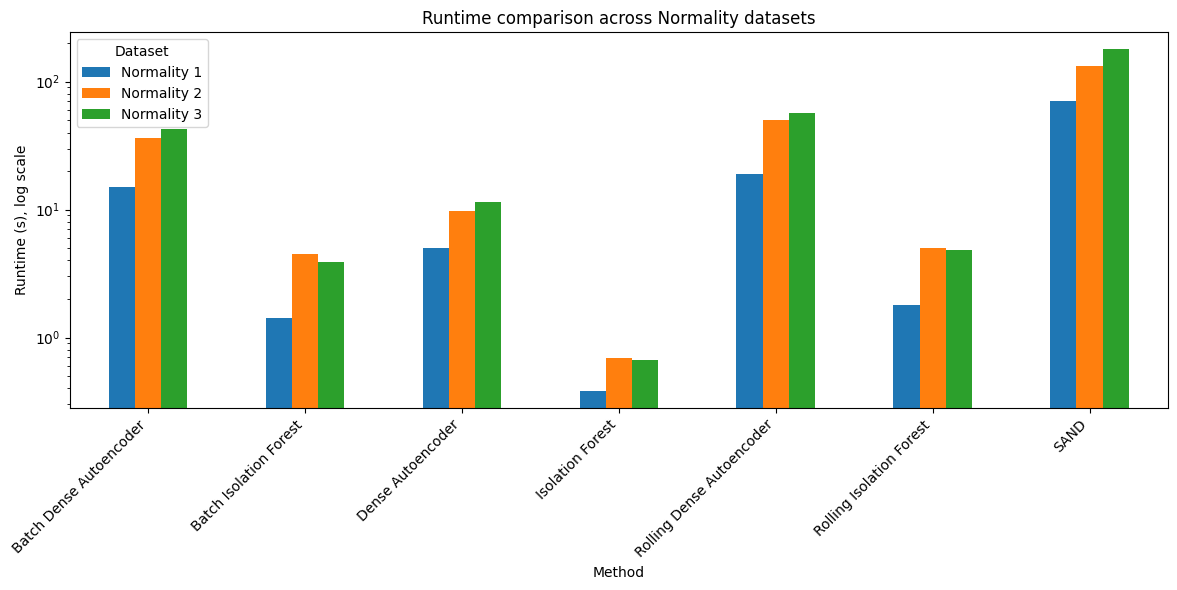

Saved: results/plots/poster_runtime_comparison.png


In [107]:
# Poster Plot 4: Runtime comparison

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("results/tables")
PLOTS_DIR = Path("results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

poster_main_results = pd.read_csv(TABLES_DIR / "poster_main_results.csv")

plot_df = poster_main_results.pivot(
    index="Method",
    columns="Dataset",
    values="Runtime (s)"
)

ax = plot_df.plot(kind="bar", figsize=(12, 6), logy=True)

ax.set_title("Runtime comparison across Normality datasets")
ax.set_xlabel("Method")
ax.set_ylabel("Runtime (s), log scale")
ax.legend(title="Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = PLOTS_DIR / "poster_runtime_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

In [108]:
# Compact poster summary table
# This keeps only the most important metrics for poster display.

all_results = pd.read_csv(TABLES_DIR / "all_results.csv")

compact_methods = [
    "SAND",
    "Batch Isolation Forest",
    "Rolling Isolation Forest",
    "Batch Dense Autoencoder",
    "Rolling Dense Autoencoder",
]

poster_compact_results = all_results[
    all_results["method"].isin(compact_methods)
].copy()

poster_compact_results = poster_compact_results[
    [
        "dataset_label",
        "method",
        "pr_auc",
        "f1",
        "accuracy",
        "runtime_seconds",
    ]
].rename(columns={
    "dataset_label": "Dataset",
    "method": "Method",
    "pr_auc": "PR-AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "runtime_seconds": "Runtime (s)",
})

poster_compact_results.to_csv(
    TABLES_DIR / "poster_compact_results.csv",
    index=False,
)

print("Saved:", TABLES_DIR / "poster_compact_results.csv")
display(poster_compact_results)

Saved: results/tables/poster_compact_results.csv


,Dataset,Method,PR-AUC,F1,Accuracy,Runtime (s)
2,Normality 1,SAND,0.0574,0.0418,0.9207,70.1927
3,Normality 1,Batch Dense Autoencoder,0.2148,0.2786,0.9403,15.1045
4,Normality 1,Batch Isolation Forest,0.4254,0.4939,0.9581,1.4090
5,Normality 1,Rolling Dense Autoencoder,0.2063,0.2602,0.9388,19.0074
6,Normality 1,Rolling Isolation Forest,0.5129,0.5969,0.9666,1.8067
10,Normality 2,SAND,0.0472,0.0616,0.9251,131.6640
11,Normality 2,Batch Dense Autoencoder,0.0710,0.1636,0.9332,36.4265
12,Normality 2,Batch Isolation Forest,0.0968,0.2318,0.9387,4.5344
13,Normality 2,Rolling Dense Autoencoder,0.0687,0.1689,0.9336,50.0190
14,Normality 2,Rolling Isolation Forest,0.1590,0.2630,0.9412,5.0456


In [119]:
%cd /content/streamify-ts-anomaly-detection
!pwd
!git status

/content/streamify-ts-anomaly-detection
/content/streamify-ts-anomaly-detection
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   streamify-ts-anomaly-detection (untracked content)

no changes added to commit (use "git add" and/or "git commit -a")


In [120]:
!git rm --cached streamify-ts-anomaly-detection

rm 'streamify-ts-anomaly-detection'


In [121]:
!rm -rf streamify-ts-anomaly-detection

In [122]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    streamify-ts-anomaly-detection



In [123]:
!git commit --amend --no-edit

[main 3838eee] Add final evaluation tables and poster outputs
 Date: Mon Jun 8 20:18:36 2026 +0000
 12 files changed, 109 insertions(+)
 create mode 100644 results/plots/poster_accuracy_comparison.png
 create mode 100644 results/plots/poster_f1_comparison.png
 create mode 100644 results/plots/poster_pr_auc_comparison.png
 create mode 100644 results/plots/poster_runtime_comparison.png
 create mode 100644 results/tables/all_results.csv
 create mode 100644 results/tables/poster_ae_variants.csv
 create mode 100644 results/tables/poster_best_methods.csv
 create mode 100644 results/tables/poster_compact_results.csv
 create mode 100644 results/tables/poster_dataset_table.csv
 create mode 100644 results/tables/poster_main_results.csv
 create mode 100644 results/tables/poster_methods_table.csv
 create mode 100644 results/tables/poster_variant_comparison.csv


In [130]:
!git status -sb
!git log --oneline -3

## main...origin/main [ahead 1]
3838eee (HEAD -> main) Add final evaluation tables and poster outputs
d5c2277 (origin/main, origin/HEAD) - Changes on notebook for better code execution - Update README
8cc6157 Add fine-tuning autoencoder variants on notebook


In [125]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [132]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [131]:
!git remote set-url origin https://github.com/OrestisGeo/streamify-ts-anomaly-detection.git

In [127]:
!git config user.name "Orestis Geo"
!git config user.email "orestis.georgiadis@gmail.com"

In [112]:
!git add .
!git commit -m "Add final evaluation tables and poster outputs"
!git push origin main

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> streamify-ts-anomaly-detection
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached streamify-ts-anomaly-detection
hint: 
hint: See "git help submodule" for more information.
[main 8f2e063] Add final evaluation tables and poster outputs
 13 files changed, 110 insertions(+)
 create mode 100644 results/plots/poster_accuracy_comparison.png
 create mode 100644 results/plots/poster_f1_comparison.png
 create mode 100644 results/plots/poster_pr_auc_comparison.png
 create mode 100644 results/plots/poster_runtime_comparison.png
 create mode 100644 results/tables/all_results.csv
 create mode 100644 results/tables/poster_ae_variants.csv
 cre

In [113]:
%cd /content/streamify-ts-anomaly-detection
!git log --oneline -5
!git status

/content/streamify-ts-anomaly-detection
8f2e063 (HEAD -> main) Add final evaluation tables and poster outputs
d5c2277 (origin/main, origin/HEAD) - Changes on notebook for better code execution - Update README
8cc6157 Add fine-tuning autoencoder variants on notebook
8df26d7 Add fine-tuning autoencoder variant results
54c4aa8 Add selective fine-tuning autoencoder variant
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   streamify-ts-anomaly-detection (untracked content)

no changes added to commit (use "git add" and/or "git commit -a")
